# OmniWaterMask on a cloudy Sentinel-2 scene — mask clouds first with OmniCloudMask

Clouds and cloud shadows are one of the most common sources of **false water
detections** in optical imagery. The recommended workflow for cloudy scenes is
to **mask clouds with [OmniCloudMask](https://github.com/DPIRD-DMA/OmniCloudMask)
(OCM) *before* running OmniWaterMask (OWM)**: set cloudy/shadowed pixels to OWM's
`no_data_value` (0) so they are excluded from inference.

This notebook walks through that workflow end to end:

1. Load a cloudy Sentinel-2 L2A scene over **Sydney** from **AWS Earth Search**
   (Element 84).
2. Read a small window over Sydney Harbour (plenty of
   water *and* cloud) at native **10 m**.
3. Pull the **RGB + NIR** bands.
4. **Mask clouds & shadows with OmniCloudMask**, zeroing them to OWM's no-data value.
5. Run **OmniWaterMask** on the cloud-masked input.
6. Visualise the cloud mask and the resulting water mask.

Requires `pystac-client` and `omnicloudmask`
(`pip install pystac-client omnicloudmask`).

In [1]:
from pathlib import Path

import numpy as np
import rasterio as rio
from rasterio.windows import Window
import pystac_client
from matplotlib import pyplot as plt

from omnicloudmask import predict_from_array
from omniwatermask import make_water_mask
import omniwatermask
from tqdm.auto import tqdm

omniwatermask.__version__

'0.1.dev49+g6589e0539.d20260603'

## 1. Load the cloudy Sydney scene

Sentinel-2 tile **56HLH** covers Sydney. We grab one scene by id and read a
1500 px window centred on Sydney Harbour, which contains plenty of
water and cloud.

In [2]:
SCENE_ID = "S2A_56HLH_20231011_0_L2A"  # ~22% cloud, Sydney
WIN = 1500  # 1500 px @ 10 m = 15 km crop
COL_OFF, ROW_OFF = 3057, 3833  # window over Sydney Harbour / Botany Bay
window = Window(col_off=COL_OFF, row_off=ROW_OFF, width=WIN, height=WIN)

catalog = pystac_client.Client.open("https://earth-search.aws.element84.com/v1")
item = next(catalog.search(collections=["sentinel-2-l2a"], ids=[SCENE_ID]).items())

print("Scene id   :", item.id)
print("Datetime   :", item.properties["datetime"])
print("Cloud cover:", round(item.properties["eo:cloud_cover"], 1), "%")

Scene id   : S2A_56HLH_20231011_0_L2A
Datetime   : 2023-10-11T00:06:06.750000Z
Cloud cover: 22.1 %


## 2. Read RGB + NIR at 10 m

red (B04), green (B03), blue (B02) and nir (B08) are all native **10 m** bands.
We read the window in OWM's expected **R, G, B, NIR** order.

In [3]:
band_assets = ["red", "green", "blue", "nir"]
bands = []
profile = None
for asset_key in tqdm(band_assets):
    with rio.open(item.assets[asset_key].href) as src:
        bands.append(src.read(1, window=window))
        if profile is None:
            profile = src.profile.copy()
            win_transform = src.window_transform(window)
stack = np.stack(bands)  # (4, WIN, WIN) -> R, G, B, NIR
stack.shape

  0%|          | 0/4 [00:00<?, ?it/s]

(4, 1500, 1500)

## 3. Mask clouds with OmniCloudMask — *before* inference

OmniCloudMask takes **Red, Green, NIR** and returns a per-pixel class map where
**class 0 = clear** (the other classes are thick cloud, thin cloud and cloud
shadow). We keep the clear pixels and **zero out everything else**.

Because OWM's default `no_data_value` is `0`, setting cloudy pixels to 0 means
OWM simply skips them — no water is predicted under cloud or shadow. We then save
the cloud-masked stack to a GeoTIFF for inference.

In [4]:
# OmniCloudMask classes: 0 = clear, 1 = thick cloud, 2 = thin cloud, 3 = cloud shadow
cloud_classes = predict_from_array(stack[[0, 1, 3]])[0]  # (WIN, WIN)
clear_mask = cloud_classes == 0  # True where clear
cloud_mask = ~clear_mask  # True where cloud/shadow

# Zero out cloudy pixels so OWM reads them as no_data (0).
stack_masked = stack * clear_mask

profile.update(
    driver="GTiff",
    height=WIN,
    width=WIN,
    count=4,
    dtype=stack.dtype,
    transform=win_transform,
    compress="deflate",
)
Path("data").mkdir(exist_ok=True)
scene_path = Path("data") / f"{item.id}_RGBNIR_cloudmasked.tif"
with rio.open(scene_path, "w", **profile) as dst:
    dst.write(stack_masked)

pct_masked = 100 * cloud_mask.mean()
print(f"Masked {pct_masked:.1f}% of pixels as cloud/shadow")
print("Wrote", scene_path)

Masked 46.8% of pixels as cloud/shadow
Wrote data/S2A_56HLH_20231011_0_L2A_RGBNIR_cloudmasked.tif


## 4. Run OmniWaterMask on the cloud-masked input

The bands are in R, G, B, NIR order, so `band_order=[1, 2, 3, 4]`. The cloudy
pixels we zeroed are treated as no-data and excluded from the water prediction.
The output GeoTIFF has a single `Water predictions` band; no-data is stored as an
embedded GDAL mask (so GIS software shows it as transparent).

In [5]:
water_paths = make_water_mask(
    scene_paths=[scene_path],
    band_order=[1, 2, 3, 4],  # RGB + NIR
    output_dir=Path("data"),
    overwrite=True,
    batch_size=1,
    inference_dtype="bf16",  # use torch.float32 if your hardware lacks bf16
)
water_mask_path = water_paths[0]
water_mask_path

Using cuda:   0%|          | 0/1 [00:00<?, ?it/s]

/home/nick/Documents/Work code/OmniWaterMask/.venv/lib/python3.13/site-packages/omnicloudmask/cloud_mask.py:274: UserWarning: Significant no-data areas detected. Adjusting patch size to 750px and overlap to 300px to minimize no-data patches.
  patch_overlap, patch_size = check_patch_size(


Path('data/S2A_56HLH_20231011_0_L2A_RGBNIR_cloudmasked_OmniWaterMask_0.1.dev49+g6589e0539.d20260603.tif')

## 5. Visualise the workflow

All three panels share the same true-colour imagery as a base. **Left:** the raw
crop (note the cloud). **Middle:** the OmniCloudMask classes — thick cloud, thin
cloud and cloud shadow overlaid in colour, with clear pixels left as imagery.
**Right:** the same, plus the OWM water prediction — water is found on the clear
pixels, while cloud/shadow areas are excluded from inference.

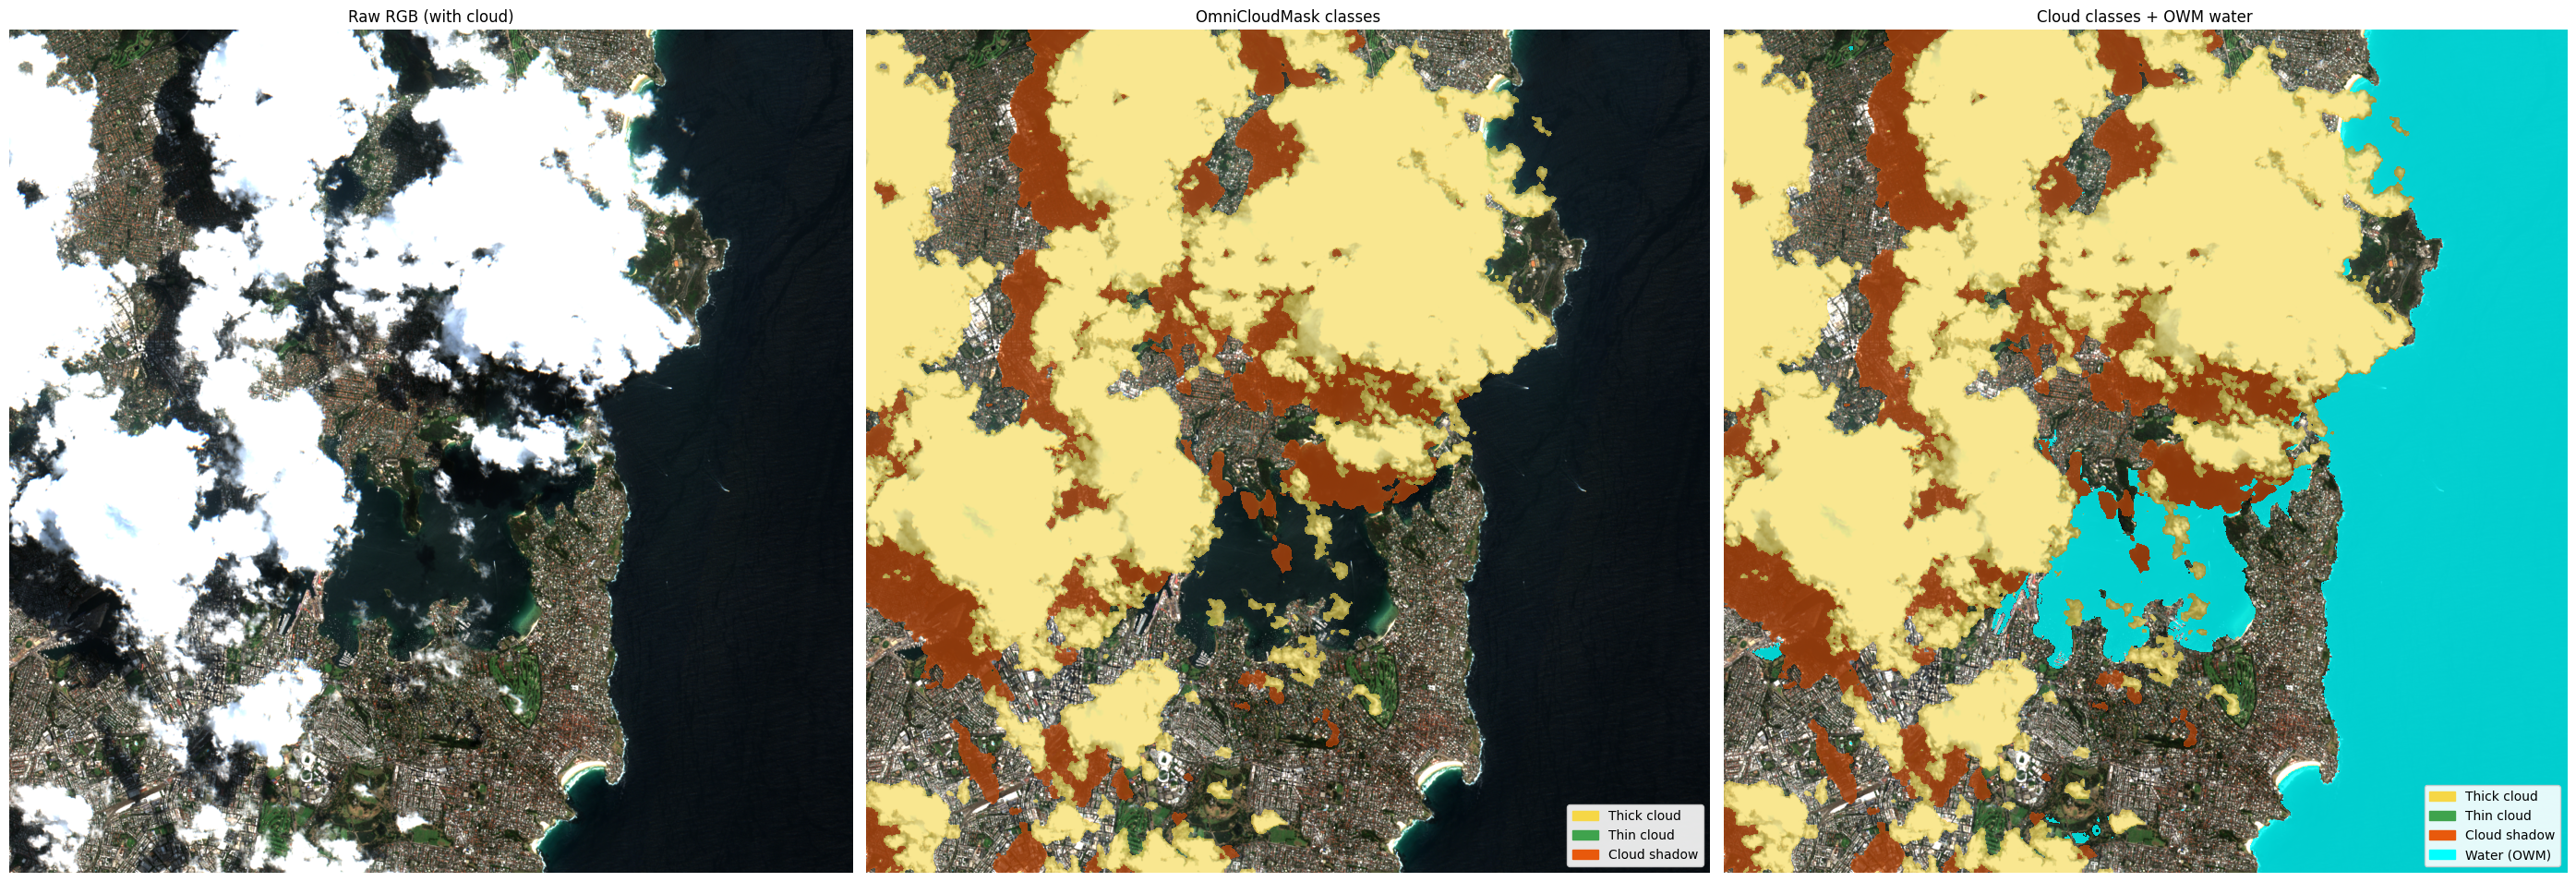

In [6]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


def to_rgb(arr):
    """True-colour RGB (bands 0,1,2 = R,G,B), scaled for display."""
    return np.clip(arr[:3].transpose(1, 2, 0).astype("float32") / 3000.0, 0, 1)


# Distinct colour per cloud class; clear (class 0) is left transparent so the
# underlying imagery shows through.
class_names = ["Thick cloud", "Thin cloud", "Cloud shadow"]
class_colors = ["#f6d746", "#3fa34d", "#e8590c"]
cloud_cmap = ListedColormap(["#000000"] + class_colors)  # index 0 unused (masked)
cloud_overlay = np.ma.masked_where(cloud_classes == 0, cloud_classes)

with rio.open(water_mask_path) as src:
    water = src.read(1)  # band 1 = water predictions (1 = water)
water_overlay = np.ma.masked_where(water == 0, water)

cloud_legend = [
    Patch(color=c, label=n) for c, n in zip(class_colors, class_names, strict=True)
]


def show_clouds(a):
    a.imshow(
        cloud_overlay,
        cmap=cloud_cmap,
        vmin=0,
        vmax=3,
        alpha=0.6,
        interpolation="nearest",
    )


fig, ax = plt.subplots(1, 3, figsize=(28, 10))
ax[0].imshow(to_rgb(stack))
ax[0].set_title("Raw RGB (with cloud)")

ax[1].imshow(to_rgb(stack))
show_clouds(ax[1])
ax[1].set_title("OmniCloudMask classes")
ax[1].legend(handles=cloud_legend, loc="lower right", framealpha=0.9)

ax[2].imshow(to_rgb(stack))
show_clouds(ax[2])
ax[2].imshow(water_overlay, cmap="cool", alpha=0.8, interpolation="nearest")
ax[2].set_title("Cloud classes + OWM water")
ax[2].legend(
    handles=cloud_legend + [Patch(color="cyan", label="Water (OWM)")],
    loc="lower right",
    framealpha=0.9,
)

for a in ax:
    a.axis("off")
plt.tight_layout()